# Predicción de Recompra de Clientes — Online Retail II

**Autor:** Ricardo Guerrero · Máster en Data Science & IA

---

## Contexto y objetivo

El encargo de negocio, en un retailer online, es identificar qué clientes tienen alta probabilidad de volver a comprar para poder tratarlos de forma distinta: acciones de fidelización con los que es probable que vuelvan y acciones de retención con los que parecen en riesgo de marcharse.

El entregable es un modelo que asigna a cada cliente una probabilidad de recompra en los próximos 6 meses, junto con la lectura de negocio necesaria para actuar sobre ella.

## Cómo está organizado el notebook

El flujo es el habitual de un proyecto de clasificación: carga y revisión de la calidad de los datos, limpieza, construcción del target con una ventana temporal, ingeniería de variables, exploración con tratamiento de outliers y transformaciones, partición temporal, comparación de modelos, optimización del ganador con Optuna, elección del umbral según el coste de negocio, explicabilidad con SHAP y, por último, la segmentación accionable.

Hay cuatro decisiones que conviene tener claras desde el principio porque condicionan todo lo demás:

1. El target se calcula sobre una ventana temporal cerrada y separada de la de las variables, para no colar información del futuro.
2. La partición no es aleatoria sino temporal (se entrena en un período y se valida en el siguiente), porque los datos tienen componente temporal.
3. La métrica que se optimiza es el ROC-AUC, porque no depende del umbral.
4. El umbral de decisión final no se deja en 0.5: se fija según lo que cuesta cada tipo de error.

## 0. Entorno y dependencias

In [1]:
# Importaciones y configuración del entorno
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier)
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, RocCurveDisplay,
    confusion_matrix, f1_score, precision_score, recall_score,
    cohen_kappa_score, matthews_corrcoef, average_precision_score
)

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
PALETA = {"azul": "#2563EB", "verde": "#10B981", "ambar": "#F59E0B",
          "rojo": "#EF4444", "gris": "#94A3B8", "morado": "#8B5CF6"}
print("Entorno configurado correctamente.")

Entorno configurado correctamente.


## 1. Carga de datos y diccionario de variables

El dataset Online Retail II recoge 24 meses de transacciones (del 01/12/2009 al 09/12/2011) de un retailer online británico de artículos de regalo, con bastante peso de clientes mayoristas. Viene en dos hojas de Excel que se juntan en un único DataFrame.

| Variable | Tipo | Descripción |
|---|---|---|
| `Invoice` | Nominal | Nº de factura (6 dígitos). El prefijo `C` indica cancelación o devolución |
| `StockCode` | Nominal | Código único de producto |
| `Description` | Nominal | Nombre del producto |
| `Quantity` | Numérica | Unidades por línea de transacción (negativa en devoluciones) |
| `InvoiceDate` | Fecha | Fecha y hora de la transacción |
| `Price` | Numérica | Precio unitario (£) |
| `Customer ID` | Nominal | Identificador único de cliente |
| `Country` | Nominal | País de residencia del cliente |

In [2]:

EXCEL_PATHS = [Path("../online_retail_II.xlsx"), Path("online_retail_II.xlsx")]

DATA_PATH = next((p for p in EXCEL_PATHS if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró online_retail_II.xlsx.")

xl = pd.ExcelFile(DATA_PATH)

df_raw = pd.concat(
    [pd.read_excel(xl, sheet_name=sheet) for sheet in xl.sheet_names],
    ignore_index=True
)

print(f"Dataset unificado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")


Dataset unificado: 1,067,371 filas × 8 columnas


In [3]:
# Resumen de calidad de datos
def resumen_variables(df):
    return (pd.DataFrame({
        "dtype": df.dtypes,
        "nulos": df.isnull().sum(),
        "pct_nulos (%)": (df.isnull().mean() * 100).round(2),
        "n_unique": df.nunique()
    }).sort_values("pct_nulos (%)", ascending=False))

display(resumen_variables(df_raw))
display(df_raw.head())

,dtype,nulos,pct_nulos (%),n_unique
Customer ID,float64,243007,22.7700,5942
Description,object,4382,0.4100,5698
StockCode,object,0,0.0000,5305
Invoice,object,0,0.0000,53628
Quantity,int64,0,0.0000,1057
InvoiceDate,datetime64[ns],0,0.0000,47635
Price,float64,0,0.0000,2807
Country,object,0,0.0000,43


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.9500,13085.0000,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,13085.0000,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,13085.0000,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.1000,13085.0000,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.2500,13085.0000,United Kingdom


### Qué nos dice la calidad de los datos

Hay dos cosas que marcan cómo se preparan los datos a partir de aquí:

- `Customer ID` tiene alrededor de un 22% de nulos. Sin identificador no se puede reconstruir el historial de un cliente ni, por tanto, predecir si volverá. Esos registros se eliminan: aquí un nulo significa "no podemos seguir a este cliente", no un dato recuperable.
- `Description` y `Price` tienen algunos nulos sueltos, y aparecen transacciones con `Price ≤ 0` (ajustes logísticos o errores de sistema) que no reflejan una compra real.

## 2. Limpieza de datos

| Criterio de exclusión | Motivo |
|---|---|
| `Customer ID` nulo | Sin ID no hay forma de seguir al cliente |
| `Price ≤ 0` | Ajustes contables o errores, no compras reales |
| Facturas `C…` (devoluciones) | Se conservan como señal de comportamiento, pero no cuentan como compra positiva |

Conservar las devoluciones en lugar de borrarlas es una decisión consciente: un cliente que devuelve sigue siendo un cliente activo, y su patrón de devoluciones aporta información útil para predecir.

In [4]:
df_clean = df_raw.dropna(subset=['Customer ID']).copy()
df_clean = df_clean[df_clean['Price'] > 0].copy()

df_clean['Is_Return']   = df_clean['Invoice'].astype(str).str.startswith('C').astype(int)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Revenue']     = df_clean['Quantity'] * df_clean['Price']
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int).astype(str)

print(f"Transacciones tras limpieza : {df_clean.shape[0]:,}")
print(f"Datos conservados           : {len(df_clean)/len(df_raw)*100:.1f}%")
print(f"Devoluciones conservadas    : {df_clean['Is_Return'].sum():,}")
print(f"Clientes únicos             : {df_clean['Customer ID'].nunique():,}")

Transacciones tras limpieza : 824,293
Datos conservados           : 77.2%
Devoluciones conservadas    : 18,744
Clientes únicos             : 5,939


## 3. Construcción temporal del target (validación walk-forward)

Definir bien el target es la parte más delicada del proyecto. Para que el modelo sirva, las variables y el target tienen que vivir en ventanas de tiempo separadas:

- Ventana de features: todo lo que hizo el cliente antes de una fecha de corte.
- Ventana de target: los 180 días siguientes a ese corte.
- `Target = 1` si el cliente hace al menos una compra real (no una devolución) en esa ventana de 180 días; `0` si no compra (churn).

### Por qué dos cortes y no uno

Una primera versión usaba un único corte y construía el test ordenando a los clientes por `Recency`, dejando como test al 20% más reciente. Pero eso no es una partición temporal: `Recency` es precisamente la variable más predictiva, así que al separar por ella el test se llena de clientes "fáciles" (un 84% de recompra frente al 44% del train) y el AUC sale inflado.

La forma correcta de validar un modelo que predice el futuro es entrenar en un período y validar en el siguiente. Es lo que se conoce como validación *walk-forward* y reproduce cómo se usaría el modelo de verdad:

| Snapshot | Corte | Features (pasado) | Target (futuro) |
|---|---|---|---|
| TRAIN | `fecha_max − 360 d` (~2010-12) | compras anteriores al corte de train | recompra en los 180 d siguientes |
| TEST  | `fecha_max − 180 d` (~2011-06) | compras anteriores al corte de test  | recompra en los 180 d siguientes |

Los dos snapshots salen de la misma función aplicada en dos fechas distintas. Sus ventanas de target van seguidas y no se solapan, y durante el entrenamiento el modelo nunca ve nada posterior a su propia ventana, así que no hay fuga temporal. Como ventaja añadida, train y test quedan con la misma estructura y tasas base parecidas (~46% y ~52%).

Un mismo cliente puede aparecer en los dos snapshots, pero con un estado distinto (su historial ha crecido) y un target distinto (otra ventana de futuro). Eso no es fuga de información: es exactamente lo que ocurre cuando se vuelve a puntuar la cartera cada cierto tiempo.

Rango de datos        : 2009-12-01 → 2011-12-09
────────────────────────────────────────────────────────────
CUTOFF TRAIN          : 2010-12-14
  features train      : 2009-12-01 → 2010-12-14
  target   train      : 2010-12-14 → 2011-06-12
CUTOFF TEST           : 2011-06-12
  features test       : 2009-12-01 → 2011-06-12
  target   test       : 2011-06-12 → 2011-12-09


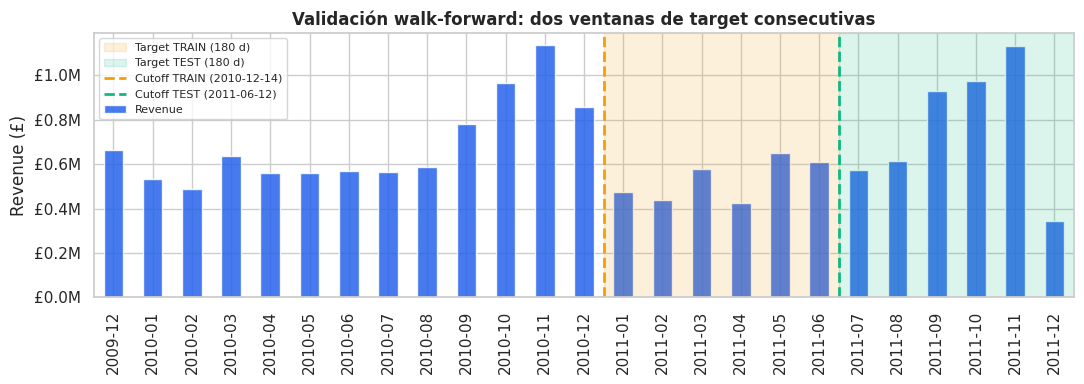

In [5]:
fecha_min = df_clean['InvoiceDate'].min()
fecha_max = df_clean['InvoiceDate'].max()

# Dos cortes consecutivos de 180 días para la validación walk-forward
HORIZON_DIAS = 180
CUTOFF_TEST  = fecha_max - pd.DateOffset(days=HORIZON_DIAS)        # snapshot de validación
CUTOFF_TRAIN = CUTOFF_TEST - pd.DateOffset(days=HORIZON_DIAS)      # snapshot de entrenamiento

print(f"Rango de datos        : {fecha_min.date()} → {fecha_max.date()}")
print("─" * 60)
print(f"CUTOFF TRAIN          : {CUTOFF_TRAIN.date()}")
print(f"  features train      : {fecha_min.date()} → {CUTOFF_TRAIN.date()}")
print(f"  target   train      : {CUTOFF_TRAIN.date()} → {CUTOFF_TEST.date()}")
print(f"CUTOFF TEST           : {CUTOFF_TEST.date()}")
print(f"  features test       : {fecha_min.date()} → {CUTOFF_TEST.date()}")
print(f"  target   test       : {CUTOFF_TEST.date()} → {fecha_max.date()}")

# Estacionalidad mensual y posición de las dos ventanas de target
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
revenue_monthly = df_clean.groupby('YearMonth')['Revenue'].sum()
df_clean.drop(columns=['YearMonth'], inplace=True)

meses = revenue_monthly.index.to_timestamp()
pos_train = np.searchsorted(meses, CUTOFF_TRAIN) - 0.5
pos_test  = np.searchsorted(meses, CUTOFF_TEST) - 0.5

fig, ax = plt.subplots(figsize=(11, 4))
revenue_monthly.plot(kind='bar', ax=ax, color=PALETA["azul"], alpha=0.85)
ax.axvspan(pos_train, pos_test, color=PALETA["ambar"], alpha=0.15, label='Target TRAIN (180 d)')
ax.axvspan(pos_test, len(revenue_monthly) - 0.5, color=PALETA["verde"], alpha=0.15, label='Target TEST (180 d)')
ax.axvline(x=pos_train, color=PALETA["ambar"], linestyle='--', linewidth=2, label=f'Cutoff TRAIN ({CUTOFF_TRAIN.date()})')
ax.axvline(x=pos_test,  color=PALETA["verde"], linestyle='--', linewidth=2, label=f'Cutoff TEST ({CUTOFF_TEST.date()})')
ax.set_title("Validación walk-forward: dos ventanas de target consecutivas",
             fontweight='bold')
ax.set_ylabel("Revenue (£)"); ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1e6:.1f}M"))
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Ingeniería de variables

A partir de la ventana de features se construye un perfil por cliente.

Variables RFM, las clásicas de retail:

| Variable | Hipótesis de negocio |
|---|---|
| `Recency_Dias` | Cuanto más reciente es la última compra, más probable es que vuelva |
| `Frecuencia_Compras` | La frecuencia histórica es el mejor proxy del hábito de compra |
| `Monetary_Gasto` | El gasto acumulado mide el valor y el compromiso del cliente |

Métricas de comportamiento:

| Variable | Hipótesis de negocio |
|---|---|
| `Tenure_Antiguedad` | Un cliente con más antigüedad tiene una relación más consolidada con la marca |
| `AOV_Ticket_Promedio` | Tamaño medio de compra; ayuda a separar perfiles de consumo |
| `Items_Promedio_Por_Cesta` | Tamaño de la cesta; distingue mayoristas de minoristas |
| `Productos_Distintos` | La variedad de catálogo comprado refleja vinculación |
| `Meses_Activos` | Nº de meses con actividad; mide la consistencia del cliente |
| `Dias_Entre_Compras` | Cadencia de compra; periódicos frente a esporádicos |
| `Ultima_Semana_Mes` | Tendencia a comprar a fin de mes (patrón corporativo o mayorista) |

Señales de devoluciones:

| Variable | Hipótesis de negocio |
|---|---|
| `Total_Devoluciones` / `Monetary_Devuelto` | Volumen de fricción tras la venta |
| `Ratio_Devoluciones` | Devoluciones normalizadas por frecuencia (más robusto que el conteo a secas) |

In [6]:
# Esta función construye el perfil de cada cliente para una fecha de corte dada.
# Usa solo las compras anteriores al corte para las variables y mira los `horizon`
# días siguientes para el target. Al tenerla como función se reutiliza en los
# dos cortes (train y test) con exactamente la misma lógica, que es lo que hace
# fiable la validación walk-forward.

def build_snapshot(df, cutoff, horizon=HORIZON_DIAS):
    cutoff  = pd.Timestamp(cutoff)
    win_end = cutoff + pd.Timedelta(days=horizon)

    df_pasado = df[df['InvoiceDate'] <  cutoff]                                    # de aquí salen las variables
    df_futuro = df[(df['InvoiceDate'] >= cutoff) & (df['InvoiceDate'] < win_end)]  # de aquí sale el target
    compras   = df_pasado[df_pasado['Is_Return'] == 0]                             # compras reales, sin devoluciones

    # RFM y métricas de comportamiento
    g = compras.groupby('Customer ID').agg(
        Primera_Compra      = ('InvoiceDate', 'min'),
        Ultima_Compra       = ('InvoiceDate', 'max'),
        Frecuencia_Compras  = ('Invoice', 'nunique'),
        Monetary_Gasto      = ('Revenue', 'sum'),
        Items_Totales       = ('Quantity', 'sum'),
        Productos_Distintos = ('StockCode', 'nunique'),
    )
    g['Recency_Dias']             = (cutoff - g['Ultima_Compra']).dt.days
    g['Tenure_Antiguedad']        = (cutoff - g['Primera_Compra']).dt.days
    g['AOV_Ticket_Promedio']      = g['Monetary_Gasto'] / g['Frecuencia_Compras']
    g['Items_Promedio_Por_Cesta'] = g['Items_Totales']  / g['Frecuencia_Compras']
    g['Dias_Entre_Compras']       = np.where(
        g['Frecuencia_Compras'] > 1,
        g['Tenure_Antiguedad'] / (g['Frecuencia_Compras'] - 1),
        g['Tenure_Antiguedad'])

    meses = (compras.assign(ym=compras['InvoiceDate'].dt.to_period('M'))
             .groupby('Customer ID')['ym'].nunique().rename('Meses_Activos'))
    g = g.join(meses)

    fin_mes = (compras.assign(fin=compras['InvoiceDate'].dt.day >= 25)
               .groupby('Customer ID')['fin'].mean().rename('Ultima_Semana_Mes'))
    g = g.join(fin_mes)

    # Devoluciones (fricción tras la venta)
    dev = (df_pasado[df_pasado['Is_Return'] == 1]
           .groupby('Customer ID')
           .agg(Total_Devoluciones=('Invoice', 'nunique'),
                Monetary_Devuelto =('Revenue', 'sum')))
    g = g.join(dev, how='left')
    g[['Total_Devoluciones', 'Monetary_Devuelto']] = g[['Total_Devoluciones', 'Monetary_Devuelto']].fillna(0)
    g['Monetary_Devuelto']  = g['Monetary_Devuelto'].abs()
    g['Ratio_Devoluciones'] = g['Total_Devoluciones'] / g['Frecuencia_Compras']

    # País mayoritario del cliente (solo descriptivo, no entra al modelo)
    g['Country_Principal'] = (compras.groupby('Customer ID')['Country']
                              .agg(lambda x: x.mode()[0] if len(x) else "Unknown"))

    # Target: ¿compró de verdad en la ventana de observación?
    recompradores = set(df_futuro[df_futuro['Is_Return'] == 0]['Customer ID'].unique())
    g['Target'] = g.index.to_series().isin(recompradores).astype(int)

    g = g.drop(columns=['Primera_Compra', 'Ultima_Compra'])
    return g.reset_index()


# Los dos snapshots: train (período anterior) y test (período siguiente)
df_train_full = build_snapshot(df_clean, CUTOFF_TRAIN)
df_test_full  = build_snapshot(df_clean, CUTOFF_TEST)

# El snapshot de train es la base para el EDA y las transformaciones
df_ml = df_train_full

print(f"Snapshot TRAIN ({CUTOFF_TRAIN.date()}): {len(df_train_full):,} clientes | "
      f"recompra {df_train_full['Target'].mean():.2%}")
print(f"Snapshot TEST  ({CUTOFF_TEST.date()}): {len(df_test_full):,} clientes | "
      f"recompra {df_test_full['Target'].mean():.2%}")
print(f"\nClientes en ambos snapshots: "
      f"{len(set(df_train_full['Customer ID']) & set(df_test_full['Customer ID'])):,} "
      f"(con estado y target distintos en cada uno, no es leakage)")
display(df_ml.head())

Snapshot TRAIN (2010-12-14): 4,322 clientes | recompra 45.63%
Snapshot TEST  (2011-06-12): 4,977 clientes | recompra 51.78%

Clientes en ambos snapshots: 4,322 (con estado y target distintos en cada uno, no es leakage)


,Customer ID,Frecuencia_Compras,Monetary_Gasto,Items_Totales,Productos_Distintos,Recency_Dias,Tenure_Antiguedad,AOV_Ticket_Promedio,Items_Promedio_Por_Cesta,Dias_Entre_Compras,Meses_Activos,Ultima_Semana_Mes,Total_Devoluciones,Monetary_Devuelto,Ratio_Devoluciones,Country_Principal,Target
0,12346,11,372.8600,70,26,168,365,33.8964,6.3636,36.5000,4,0.5758,4.0000,437.5400,0.3636,United Kingdom,1
1,12347,2,2035.1100,1147,70,6,43,1017.5550,573.5000,43.0000,2,0.3922,0.0000,0.0000,0.0000,Iceland,1
2,12348,1,222.1600,373,20,77,77,222.1600,373.0000,77.0000,1,1.0000,0.0000,0.0000,0.0000,Finland,1
3,12349,3,2671.1400,993,90,47,228,890.3800,331.0000,114.0000,3,0.9902,1.0000,24.1500,0.3333,Italy,0
4,12351,1,300.9300,261,21,14,14,300.9300,261.0000,14.0000,1,1.0000,0.0000,0.0000,0.0000,Unspecified,0


## 5. Análisis exploratorio

Con el EDA se persiguen tres objetivos: ver la distribución de cada variable, localizar outliers y comprobar su relación con el target.

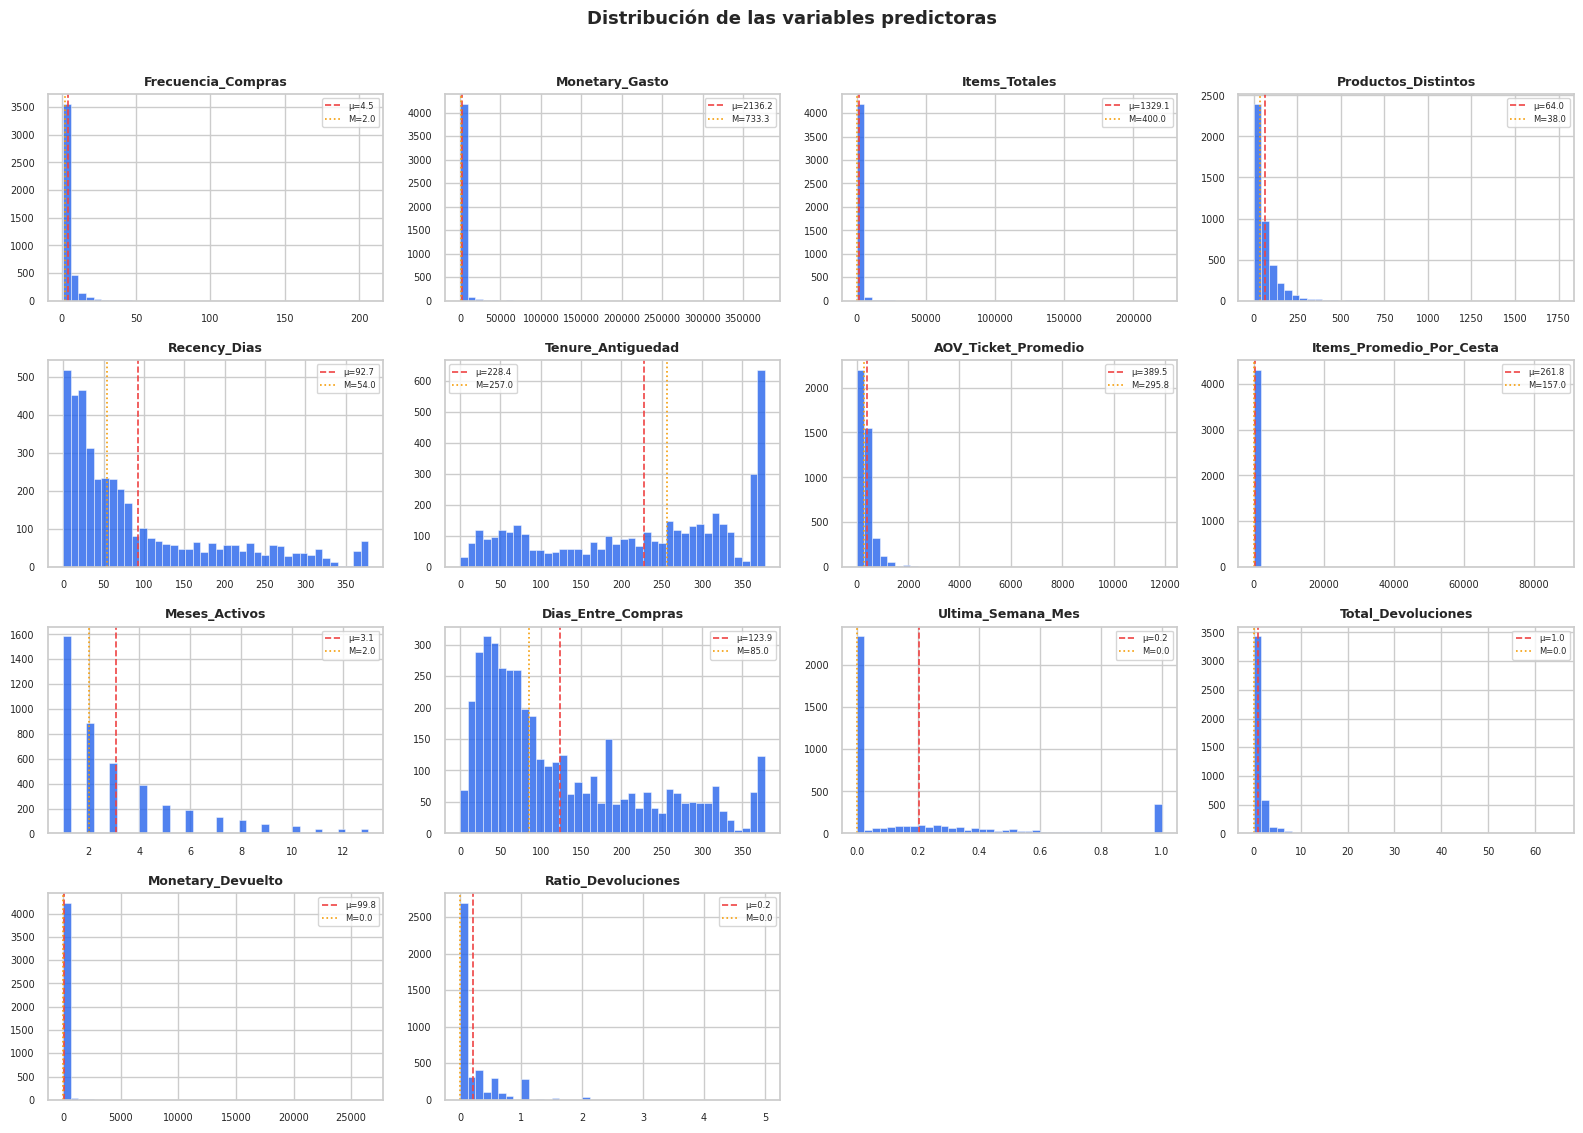

In [7]:
FEATURES_NUM = [
    'Frecuencia_Compras', 'Monetary_Gasto', 'Items_Totales', 'Productos_Distintos',
    'Recency_Dias', 'Tenure_Antiguedad', 'AOV_Ticket_Promedio',
    'Items_Promedio_Por_Cesta', 'Meses_Activos', 'Dias_Entre_Compras',
    'Ultima_Semana_Mes', 'Total_Devoluciones', 'Monetary_Devuelto', 'Ratio_Devoluciones'
]

# Distribuciones con media y mediana
n_cols = 4; n_rows = -(-len(FEATURES_NUM) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 2.8))
axes = axes.flatten()
for i, col in enumerate(FEATURES_NUM):
    ax = axes[i]; data = df_ml[col]
    ax.hist(data, bins=40, color=PALETA["azul"], alpha=0.8, edgecolor="white", linewidth=0.4)
    ax.axvline(data.mean(),   color=PALETA["rojo"],  linewidth=1.2, linestyle="--", label=f"μ={data.mean():.1f}")
    ax.axvline(data.median(), color=PALETA["ambar"], linewidth=1.2, linestyle=":",  label=f"M={data.median():.1f}")
    ax.set_title(col, fontsize=9, fontweight="bold"); ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)
for j in range(len(FEATURES_NUM), len(axes)): axes[j].set_visible(False)
plt.suptitle("Distribución de las variables predictoras", fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

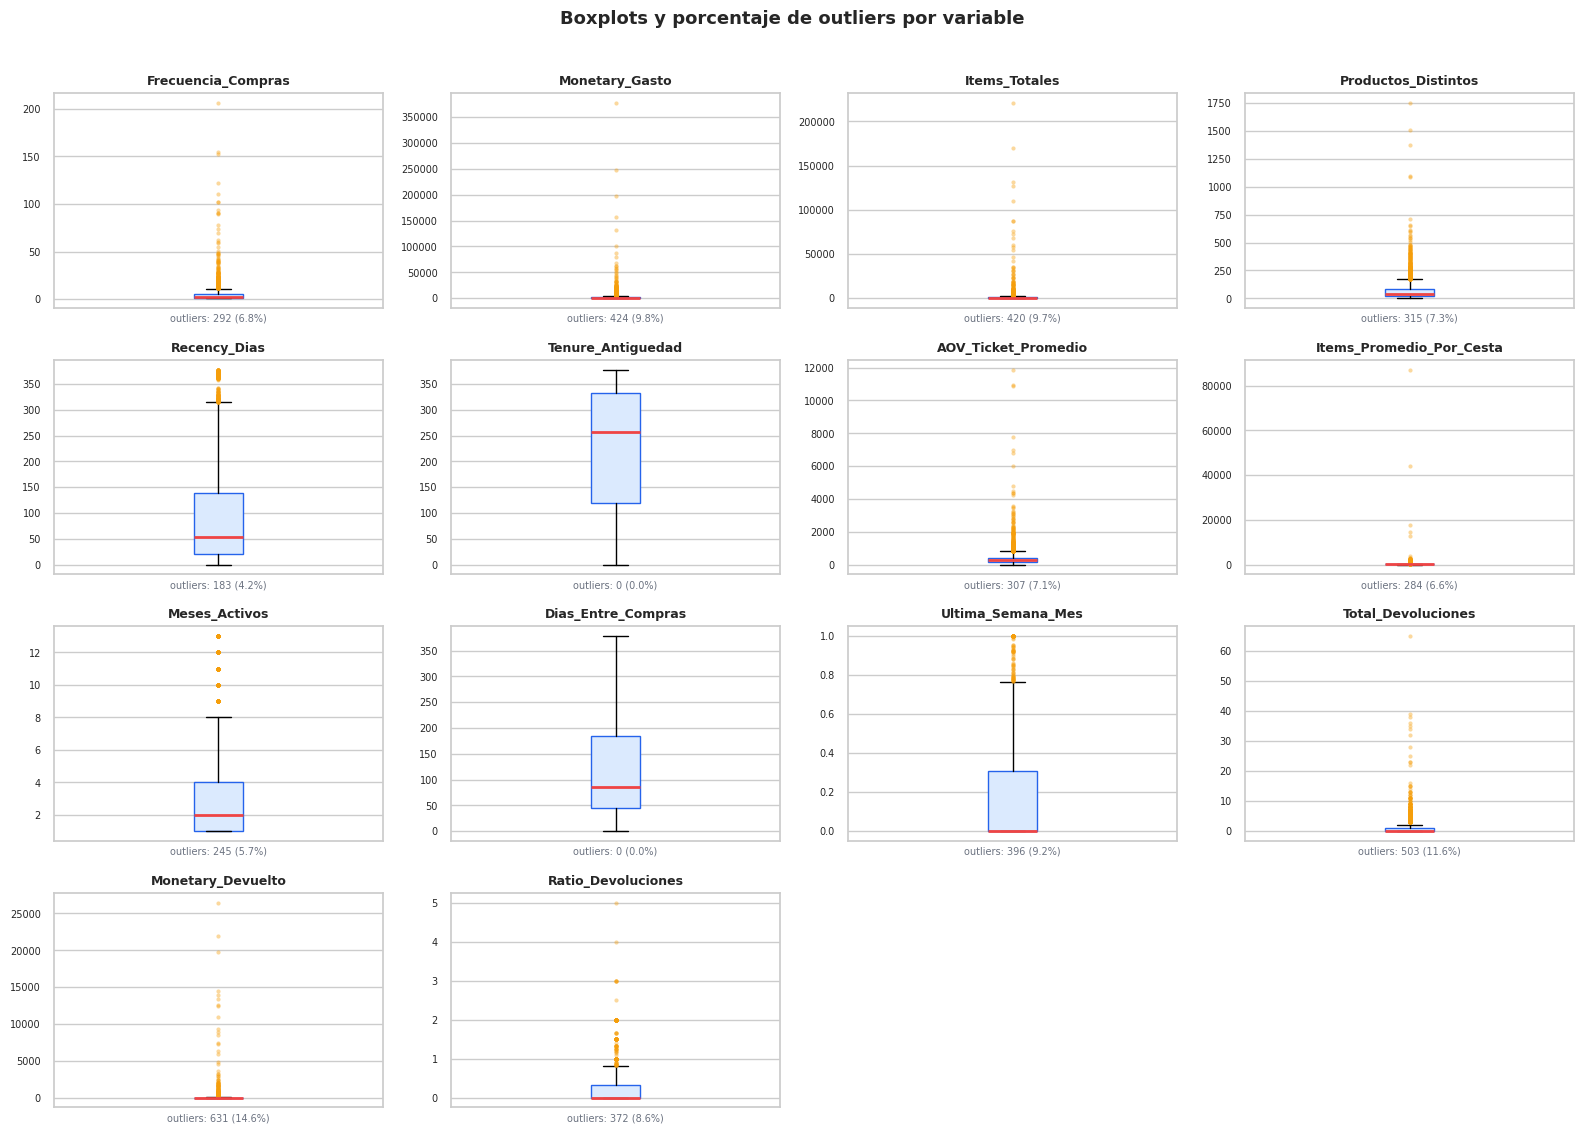

In [8]:
# Boxplots y cuantificación de outliers (regla 1.5·IQR)
n_cols = 4; n_rows = -(-len(FEATURES_NUM) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 2.8))
axes = axes.flatten()
for i, col in enumerate(FEATURES_NUM):
    ax = axes[i]; data = df_ml[col]
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor="#DBEAFE", color=PALETA["azul"]),
               medianprops=dict(color=PALETA["rojo"], linewidth=2),
               flierprops=dict(marker="o", markerfacecolor=PALETA["ambar"], markersize=3, alpha=0.4, markeredgewidth=0))
    q1, q3 = data.quantile(0.25), data.quantile(0.75); iqr = q3 - q1
    n_out = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.set_xlabel(f"outliers: {n_out} ({n_out/len(data)*100:.1f}%)", fontsize=7, color="#6B7280")
    ax.set_xticks([]); ax.tick_params(labelsize=7)
for j in range(len(FEATURES_NUM), len(axes)): axes[j].set_visible(False)
plt.suptitle("Boxplots y porcentaje de outliers por variable", fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

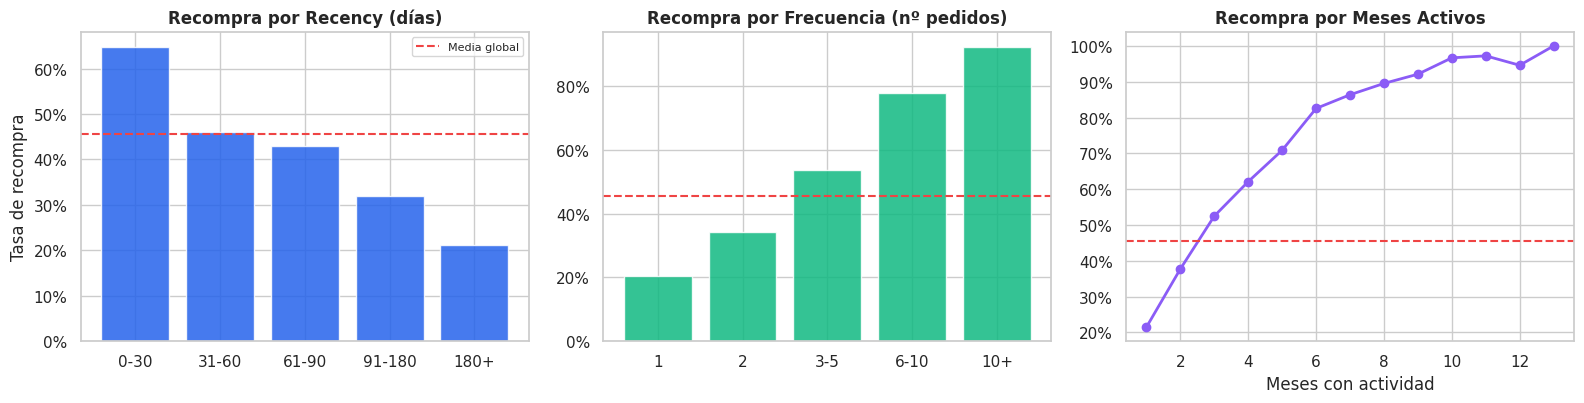

Recency va al revés que el target (a más reciente, más recompra), mientras Frecuencia y Meses Activos muestran relación creciente y monótona.


In [9]:
# Relación de las variables RFM clave con el target
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# Recency vs recompra (binned)
df_tmp = df_ml.copy()
df_tmp['Recency_bin'] = pd.cut(df_tmp['Recency_Dias'], bins=[0,30,60,90,180,400],
                               labels=["0-30","31-60","61-90","91-180","180+"])
rec = df_tmp.groupby('Recency_bin')['Target'].mean()
axes[0].bar(rec.index.astype(str), rec.values, color=PALETA["azul"], alpha=0.85)
axes[0].axhline(df_ml['Target'].mean(), color=PALETA["rojo"], linestyle="--", label="Media global")
axes[0].set_title("Recompra por Recency (días)", fontweight="bold"); axes[0].set_ylabel("Tasa de recompra")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1)); axes[0].legend(fontsize=8)

# Frecuencia vs recompra
df_tmp['Freq_bin'] = pd.cut(df_tmp['Frecuencia_Compras'], bins=[0,1,2,5,10,1000],
                            labels=["1","2","3-5","6-10","10+"])
freq = df_tmp.groupby('Freq_bin')['Target'].mean()
axes[1].bar(freq.index.astype(str), freq.values, color=PALETA["verde"], alpha=0.85)
axes[1].axhline(df_ml['Target'].mean(), color=PALETA["rojo"], linestyle="--")
axes[1].set_title("Recompra por Frecuencia (nº pedidos)", fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1))

# Meses activos vs recompra
mes = df_ml.groupby('Meses_Activos')['Target'].mean()
axes[2].plot(mes.index, mes.values, marker="o", color=PALETA["morado"], linewidth=2)
axes[2].axhline(df_ml['Target'].mean(), color=PALETA["rojo"], linestyle="--")
axes[2].set_title("Recompra por Meses Activos", fontweight="bold")
axes[2].set_xlabel("Meses con actividad")
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1))

plt.tight_layout(); plt.show()
print("Recency va al revés que el target (a más reciente, más recompra), "
      "mientras Frecuencia y Meses Activos muestran relación creciente y monótona.")

### 5.1 La variable `Country` antes de descartarla

Antes de quitar el país del modelo, se comprueba si de verdad aporta algo.

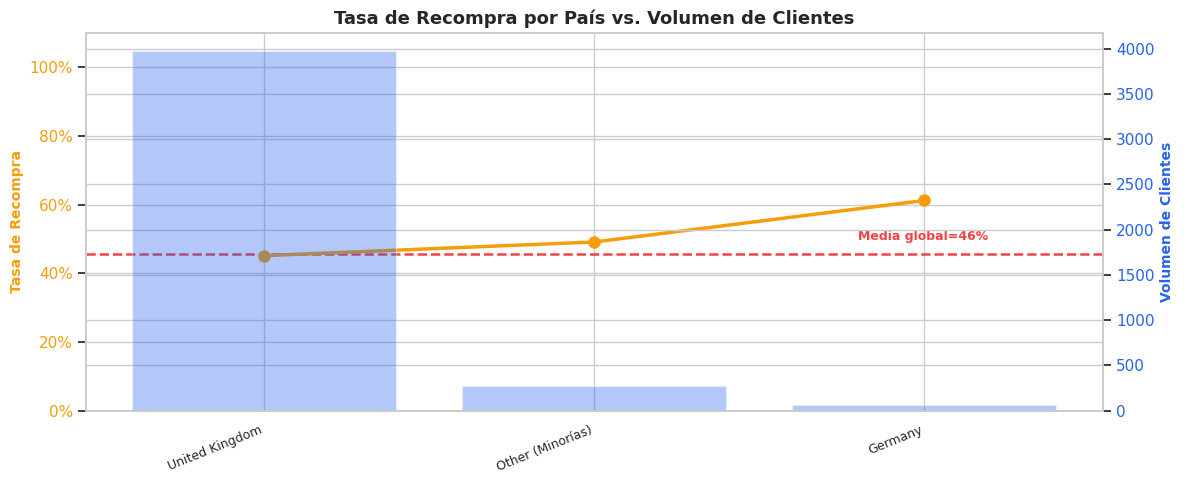

────────────────────────────────────────────────────────────
CONCLUSIÓN: UK representa >85% de los clientes con varianza
marginal en tasa de recompra. Se excluye Country del modelo.
Añadiría ruido sin una mejora apreciable del AUC.


In [10]:
def agrupar_minorias_cat(df, col, target, threshold=0.015):
    grp = df.groupby(col)[target].agg(["mean", "count"]).reset_index()
    grp.columns = [col, "retention_rate", "n"]
    min_count = df[col].count() * threshold
    main   = grp[grp["n"] >= min_count].copy()
    others = grp[grp["n"] <  min_count]
    if len(others) > 0:
        otros_row = pd.DataFrame([{
            col: "Other (Minorías)",
            "retention_rate": np.average(others["retention_rate"], weights=others["n"]),
            "n": others["n"].sum()
        }])
        main = pd.concat([main, otros_row], ignore_index=True)
    return main.sort_values("n", ascending=False)

grp = agrupar_minorias_cat(df_ml, 'Country_Principal', 'Target', threshold=0.015)

fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx()
x = np.arange(len(grp))

ax2.bar(x, grp["n"], color="#2563EB", alpha=0.35, zorder=1)
ax2.set_ylabel("Volumen de Clientes", fontsize=10, color="#2563EB", fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#2563EB")

ax.plot(x, grp["retention_rate"], color="#F59E0B", marker="o", linewidth=2.5,
        markersize=8, zorder=3)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_ylim(0, 1.1)
ax.set_ylabel("Tasa de Recompra", fontsize=10, color="#F59E0B", fontweight="bold")
ax.tick_params(axis="y", labelcolor="#F59E0B")

global_rate = df_ml["Target"].mean()
ax.axhline(global_rate, color="#EF4444", linewidth=1.8, linestyle="--")
ax.text(len(grp)-1.2, global_rate+0.04, f"Media global={global_rate:.0%}",
        fontsize=9, color="#EF4444", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(grp['Country_Principal'].astype(str), rotation=22, ha="right", fontsize=9)
ax.set_title("Tasa de Recompra por País vs. Volumen de Clientes", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

print("─"*60)
print("CONCLUSIÓN: UK representa >85% de los clientes con varianza")
print("marginal en tasa de recompra. Se excluye Country del modelo.")
print("Añadiría ruido sin una mejora apreciable del AUC.")


### 5.2 Correlaciones con el target

Se mira qué variables tienen más relación lineal con el target y si hay redundancias entre ellas (multicolinealidad).

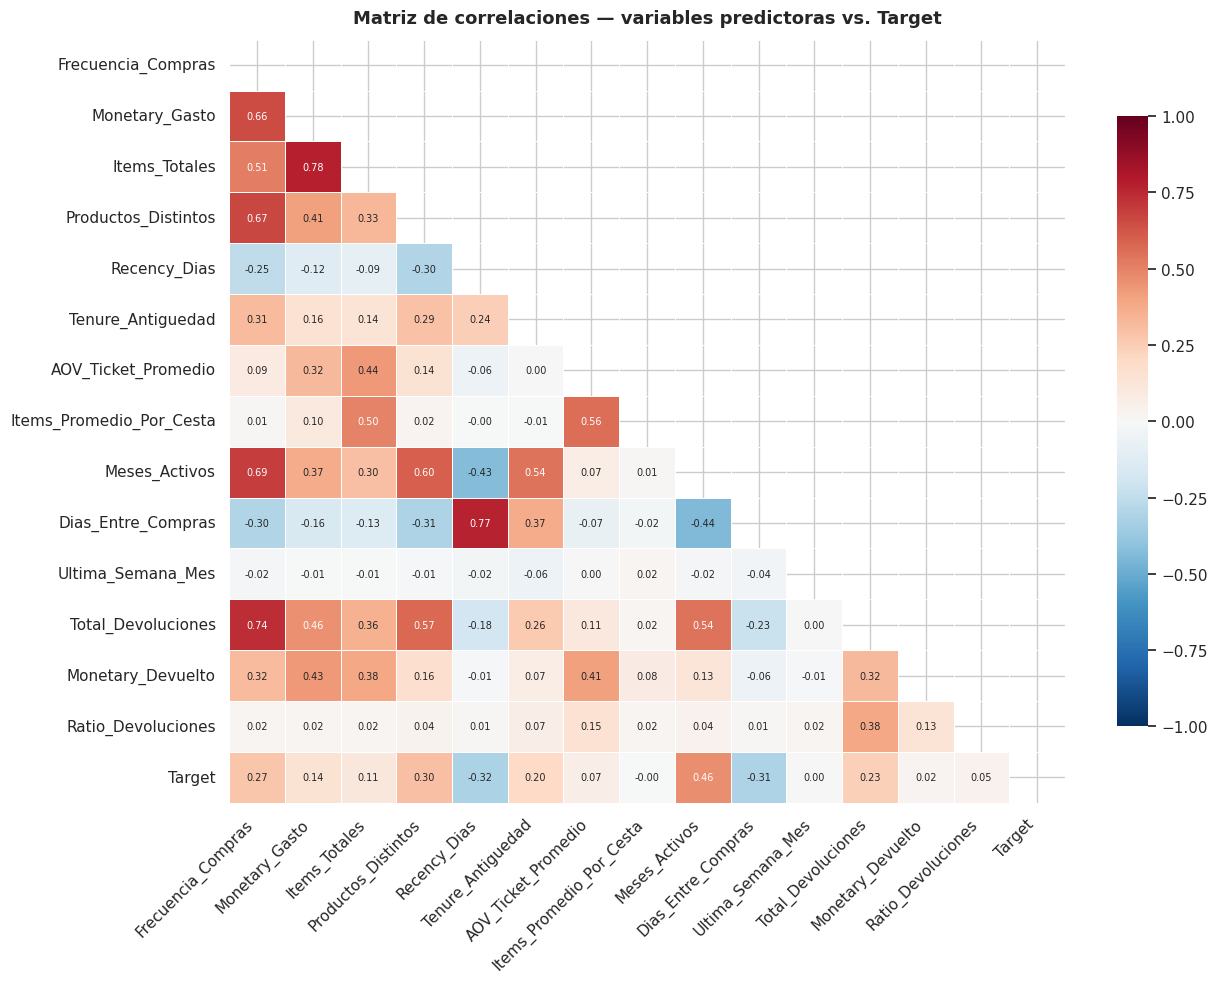

Correlación con el Target (ordenado por |r|):
Meses_Activos               0.4630
Recency_Dias               -0.3200
Dias_Entre_Compras         -0.3060
Productos_Distintos         0.2980
Frecuencia_Compras          0.2740
Total_Devoluciones          0.2350
Tenure_Antiguedad           0.1980
Monetary_Gasto              0.1450
Items_Totales               0.1120
AOV_Ticket_Promedio         0.0670
Ratio_Devoluciones          0.0460
Monetary_Devuelto           0.0250
Ultima_Semana_Mes           0.0010
Items_Promedio_Por_Cesta   -0.0000


In [11]:
corr_cols = FEATURES_NUM + ['Target']
corr = df_ml[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(13, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, linecolor="white",
            annot_kws={"size": 7}, cbar_kws={'shrink': 0.8})
plt.title("Matriz de correlaciones — variables predictoras vs. Target",
          fontweight="bold", fontsize=13, pad=12)
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

target_corr = corr['Target'].drop('Target').sort_values(key=abs, ascending=False)
print("Correlación con el Target (ordenado por |r|):")
print(target_corr.round(3).to_string())

## 6. Outliers y transformaciones

Con los outliers, no se eliminan. Los valores extremos en `Monetary_Gasto` o `Items_Totales` no son errores: son los clientes mayoristas, que es justo el segmento más valioso. Quitarlos sería descartar a quien más interesa retener. Además, los modelos de árbol (XGBoost, LightGBM) no se ven afectados por ellos, porque parten por umbrales y no por distancias.

Con las transformaciones sí se actúa. Varias variables monetarias y de conteo están muy sesgadas a la derecha. A esas se les aplica `log1p` por dos motivos: comprime las colas y estabiliza la varianza (importante para la regresión logística, que sí es sensible a la escala) y deja los gráficos de SHAP más legibles.

`log1p` no tiene parámetros, así que no aprende nada de los datos y no introduce fuga. A los árboles no les perjudica porque son invariantes a transformaciones monótonas.

In [12]:
from scipy.stats import skew

# Variables muy sesgadas a la derecha, candidatas a log1p
SKEW_FEATURES = ['Monetary_Gasto', 'Items_Totales', 'AOV_Ticket_Promedio',
                 'Productos_Distintos',
                 'Monetary_Devuelto', 'Frecuencia_Compras', 'Total_Devoluciones']

skew_antes = {c: skew(df_ml[c]) for c in SKEW_FEATURES}

for c in SKEW_FEATURES:
    df_train_full[c] = np.log1p(df_train_full[c])
    df_test_full[c]  = np.log1p(df_test_full[c])

skew_despues = {c: skew(df_ml[c]) for c in SKEW_FEATURES}

comp = pd.DataFrame({"Skew antes": skew_antes, "Skew después": skew_despues}).round(2)
print("Reducción de la asimetría tras log1p (snapshot de entrenamiento):")
display(comp)
print("\nLos nombres de columna no cambian; ahora están en escala log, "
      "lo que conviene recordar al leer los coeficientes y SHAP.")

Reducción de la asimetría tras log1p (snapshot de entrenamiento):


,Skew antes,Skew después
Monetary_Gasto,24.4400,0.2600
Items_Totales,19.8500,-0.1700
AOV_Ticket_Promedio,10.8300,-0.1000
Productos_Distintos,6.1400,-0.3300
Monetary_Devuelto,19.1400,1.0600
Frecuencia_Compras,10.5500,1.1700
Total_Devoluciones,9.7600,1.4200



Los nombres de columna no cambian; ahora están en escala log, lo que conviene recordar al leer los coeficientes y SHAP.


## 7. Partición temporal y preprocesado

La partición ya está hecha: el snapshot del corte anterior es el train y el del corte siguiente es el test.

El `StandardScaler` se ajusta solo con el train y luego se aplica al test, para no colar información de la distribución de test. Solo la regresión logística lo necesita; a los árboles la escala les da igual.

In [13]:
FEATURES = [
    'Frecuencia_Compras', 'Monetary_Gasto', 'Items_Totales', 'Productos_Distintos',
    'Recency_Dias', 'Tenure_Antiguedad', 'AOV_Ticket_Promedio',
    'Items_Promedio_Por_Cesta', 'Meses_Activos', 'Dias_Entre_Compras',
    'Ultima_Semana_Mes', 'Total_Devoluciones', 'Monetary_Devuelto', 'Ratio_Devoluciones'
]

# Cada snapshot ya es directamente un conjunto: train el del corte anterior, test el siguiente
X_train, y_train = df_train_full[FEATURES], df_train_full['Target']
X_test,  y_test  = df_test_full[FEATURES],  df_test_full['Target']

# Escalado para la regresión logística: se ajusta con train y se aplica a test
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES, index=X_test.index)

print(f"Train : {len(X_train):,} clientes (snapshot {CUTOFF_TRAIN.date()})")
print(f"Test  : {len(X_test):,} clientes (snapshot {CUTOFF_TEST.date()})")
print(f"\nTasa de recompra train : {y_train.mean():.2%}")
print(f"Tasa de recompra test  : {y_test.mean():.2%}")

Train : 4,322 clientes (snapshot 2010-12-14)
Test  : 4,977 clientes (snapshot 2011-06-12)

Tasa de recompra train : 45.63%
Tasa de recompra test  : 51.78%


### 7.1 Funciones de evaluación

Las métricas se agrupan en una única función para evaluar todos los modelos de la misma forma. Además del AUC se añaden tres métricas que aguantan bien el desbalanceo:

- Kappa de Cohen: mide el acuerdo entre predicción y realidad descontando el azar.
- MCC (Matthews): muy robusta con clases desbalanceadas (1 es perfecto, 0 es aleatorio).
- AUC-PR: área bajo la curva precision-recall, más informativa que la ROC cuando la clase positiva es minoritaria.

In [14]:
def plot_confusion_matrix(y_true, y_prob, threshold=0.5, ax=None):
    preds = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, preds, labels=[1, 0])
    if ax is None: _, ax = plt.subplots(figsize=(4.4, 3.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Recompra", "Churn"], yticklabels=["Recompra", "Churn"], ax=ax)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real"); ax.set_title("Matriz de confusión")
    return ax

def metricas(y_true, y_prob, tag, threshold=0.5, plot=True):
    """Evalúa un clasificador binario y devuelve una fila resumen para el comparador."""
    y_pred = (y_prob >= threshold).astype(int)
    auc, auc_pr = roc_auc_score(y_true, y_prob), average_precision_score(y_true, y_prob)
    rep   = classification_report(y_true, y_pred, target_names=["Churn", "Recompra"], output_dict=True)
    kappa, mcc = cohen_kappa_score(y_true, y_pred), matthews_corrcoef(y_true, y_pred)

    if plot:
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
        plot_confusion_matrix(y_true, y_prob, threshold, ax=a1)
        RocCurveDisplay.from_predictions(y_true, y_prob, ax=a2, name=tag, color=PALETA["azul"])
        a2.plot([0, 1], [0, 1], "k--", lw=1); a2.set_title(f"Curva ROC — {tag}")
        plt.tight_layout(); plt.show()

    print(f"\n{'='*55}\n  {tag}  (threshold = {threshold})\n{'='*55}")
    print(classification_report(y_true, y_pred, target_names=["Churn", "Recompra"]))
    print(f"AUC-ROC: {auc:.4f} | AUC-PR: {auc_pr:.4f} | Kappa: {kappa:.4f} | MCC: {mcc:.4f}")

    return {"Modelo": tag, "AUC-ROC": round(auc, 4), "AUC-PR": round(auc_pr, 4),
            "F1 (recompra)": round(rep["Recompra"]["f1-score"], 4),
            "Precision": round(rep["Recompra"]["precision"], 4),
            "Recall": round(rep["Recompra"]["recall"], 4),
            "Accuracy": round(rep["accuracy"], 4),
            "Kappa": round(kappa, 4), "MCC": round(mcc, 4)}

resultados = [] 
print("Funciones de evaluación cargadas.")

Funciones de evaluación cargadas.


## 8. Modelo de referencia: Regresión Logística

Se empieza con una regresión logística como punto de partida. Marca el nivel que cualquier modelo más complejo tendrá que superar para que compense su mayor coste y su menor interpretabilidad.

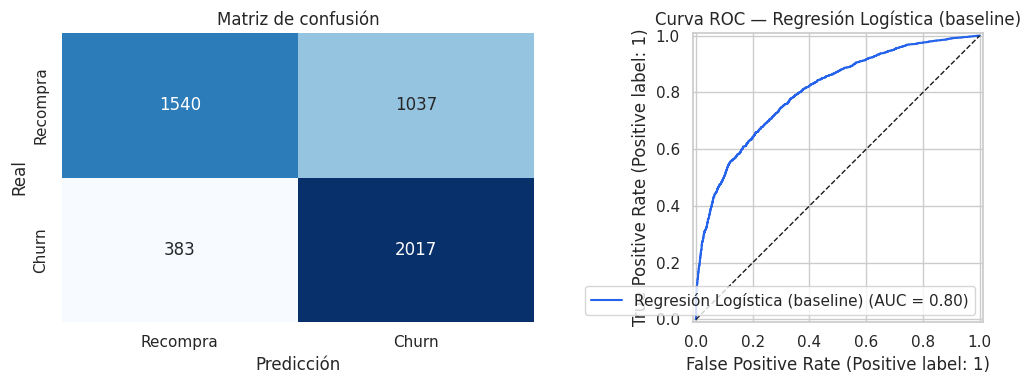


  Regresión Logística (baseline)  (threshold = 0.5)
              precision    recall  f1-score   support

       Churn       0.66      0.84      0.74      2400
    Recompra       0.80      0.60      0.68      2577

    accuracy                           0.71      4977
   macro avg       0.73      0.72      0.71      4977
weighted avg       0.73      0.71      0.71      4977

AUC-ROC: 0.8047 | AUC-PR: 0.8232 | Kappa: 0.4339 | MCC: 0.4495


In [15]:
lr_baseline = LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000)
lr_baseline.fit(X_train_sc, y_train)
y_prob_lr = lr_baseline.predict_proba(X_test_sc)[:, 1]

resultados.append(metricas(y_test, y_prob_lr, tag="Regresión Logística (baseline)"))

## 9. Comparación de algoritmos sin optimizar

Se entrenan todos los candidatos con hiperparámetros razonables pero sin búsqueda fina, incluida la regresión logística de la sección anterior. Así la comparación es justa y permite quedarse con un ganador, sea cual sea, al que luego dedicar la optimización con Optuna.

Se prueban varias familias: regresión logística (ya entrenada), Random Forest y Extra Trees (bagging), Gradient Boosting de sklearn (boosting clásico) y XGBoost y LightGBM (boosting moderno, que suele ir bien en datos tabulares).

In [16]:
scale_pw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (ratio churn/recompra): {scale_pw:.2f}\n")

candidatos_raw = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting (sklearn)": GradientBoostingClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pw, eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05, num_leaves=40,
        subsample=0.8, colsample_bytree=0.8, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
}

# Incluir LR (ya entrenada en sección 8) para comparación completa con todos los modelos
auc_lr_base = roc_auc_score(y_test, y_prob_lr)
resultados_raw = {"Regresión Logística": {"modelo": lr_baseline, "auc": auc_lr_base}}
print(f"  {'Regresión Logística':<32} AUC = {auc_lr_base:.4f}")

for nombre, modelo in candidatos_raw.items():
    modelo.fit(X_train, y_train)
    auc = roc_auc_score(y_test, modelo.predict_proba(X_test)[:, 1])
    resultados_raw[nombre] = {"modelo": modelo, "auc": auc}
    print(f"  {nombre:<32} AUC = {auc:.4f}")

scale_pos_weight (ratio churn/recompra): 1.19

  Regresión Logística              AUC = 0.8047
  Random Forest                    AUC = 0.7744
  Extra Trees                      AUC = 0.7790
  Gradient Boosting (sklearn)      AUC = 0.7490
  XGBoost                          AUC = 0.7818
  LightGBM                         AUC = 0.7757


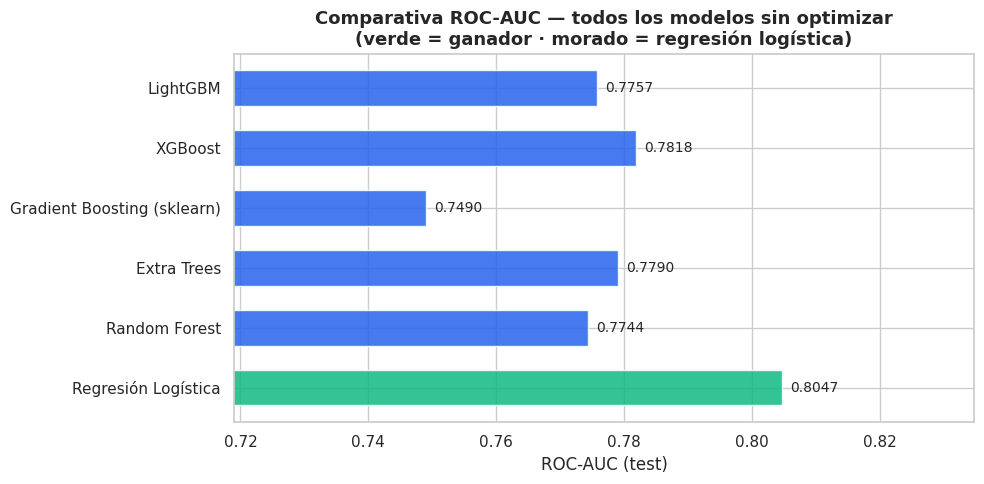

Modelo ganador: Regresión Logística (AUC = 0.8047). Lo optimizamos con Optuna.


In [17]:
# Comparativa visual — todos los modelos
nombres  = list(resultados_raw.keys())
aucs_raw = [resultados_raw[n]["auc"] for n in nombres]
best_idx = int(np.argmax(aucs_raw))

fig, ax = plt.subplots(figsize=(10, 5))
colores = [
    PALETA["verde"]  if i == best_idx
    else PALETA["morado"] if n == "Regresión Logística"
    else PALETA["azul"]
    for i, n in enumerate(nombres)
]
bars = ax.barh(nombres, aucs_raw, color=colores, alpha=0.85, height=0.6)
ax.bar_label(bars, labels=[f"{v:.4f}" for v in aucs_raw], padding=6, fontsize=10)
ax.set_xlim(min(aucs_raw) - 0.03, max(aucs_raw) + 0.03)
ax.set_title("Comparativa ROC-AUC — todos los modelos sin optimizar\n"
             "(verde = ganador · morado = regresión logística)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("ROC-AUC (test)")
plt.tight_layout(); plt.show()

mejor_nombre  = max(resultados_raw, key=lambda k: resultados_raw[k]["auc"])
mejor_auc_raw = resultados_raw[mejor_nombre]["auc"]
print(f"Modelo ganador: {mejor_nombre} (AUC = {mejor_auc_raw:.4f}). Lo optimizamos con Optuna.")

## 10. Optimización de hiperparámetros con Optuna

### Qué se optimiza en cada modelo

| Modelo | Hiperparámetros principales |
|---|---|
| Regresión Logística | `C` (regularización), `penalty` (L1/L2/ElasticNet) y `l1_ratio` |
| XGBoost / LightGBM | `n_estimators`, `max_depth`, `learning_rate`, `subsample`, regularización |
| Random Forest / Extra Trees | `n_estimators`, `max_depth`, `max_features`, `min_samples_*` |

En el split interno de validación de cada trial se usa `shuffle=False` para no romper el orden temporal. El umbral de decisión no se toca aquí; se elige más adelante, en la parte de coste de negocio.

### Selección final del modelo

La búsqueda de hiperparámetros no siempre mejora la configuración por defecto: en modelos bien regularizados, esta ya puede estar cerca del óptimo. Por eso, tras optimizar, se compara el modelo ajustado con el baseline sobre el período de validación y se conserva el que mejor generaliza. Si la optimización no aporta mejora, se prefiere el modelo por defecto por ser más simple e igual de eficaz.

In [18]:
from sklearn.pipeline import Pipeline

def make_objective(nombre):
    """Devuelve la función objetivo de Optuna para el modelo ganador.
       Split interno con shuffle=False para preservar la temporalidad."""
    def split_interno():
        Xtr, Xv, ytr, yv = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)
        if yv.nunique() < 2 or ytr.nunique() < 2:
            Xtr, Xv, ytr, yv = train_test_split(
                X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train)
        return Xtr, Xv, ytr, yv

    def obj_lr(trial):
        C       = trial.suggest_float("C", 1e-4, 100, log=True)
        penalty = trial.suggest_categorical("penalty", ["l1", "l2", "elasticnet"])
        lr_kw   = dict(C=C, penalty=penalty, solver="saga", class_weight="balanced",
                       max_iter=2000, random_state=RANDOM_STATE)
        if penalty == "elasticnet":
            lr_kw["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)
        Xtr, Xv, ytr, yv = split_interno()
        sc = StandardScaler()
        m  = LogisticRegression(**lr_kw)
        m.fit(sc.fit_transform(Xtr), ytr)
        return roc_auc_score(yv, m.predict_proba(sc.transform(Xv))[:, 1])

    def obj_xgb(trial):
        p = {"n_estimators":      trial.suggest_int("n_estimators", 200, 800),
             "max_depth":         trial.suggest_int("max_depth", 3, 8),
             "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
             "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
             "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
             "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
             "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
             "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
             "scale_pos_weight": scale_pw, "eval_metric": "auc",
             "random_state": RANDOM_STATE, "n_jobs": -1}
        Xtr, Xv, ytr, yv = split_interno()
        m = xgb.XGBClassifier(**p); m.fit(Xtr, ytr, verbose=False)
        return roc_auc_score(yv, m.predict_proba(Xv)[:, 1])

    def obj_lgbm(trial):
        p = {"n_estimators":       trial.suggest_int("n_estimators", 200, 800),
             "max_depth":          trial.suggest_int("max_depth", 3, 8),
             "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
             "num_leaves":         trial.suggest_int("num_leaves", 20, 150),
             "subsample":          trial.suggest_float("subsample", 0.6, 1.0),
             "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.6, 1.0),
             "min_child_samples":  trial.suggest_int("min_child_samples", 5, 50),
             "reg_alpha":          trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
             "reg_lambda":         trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
             "class_weight": "balanced", "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": -1}
        Xtr, Xv, ytr, yv = split_interno()
        m = lgb.LGBMClassifier(**p); m.fit(Xtr, ytr)
        return roc_auc_score(yv, m.predict_proba(Xv)[:, 1])

    def obj_trees(trial, Clase):
        p = {"n_estimators":     trial.suggest_int("n_estimators", 200, 800),
             "max_depth":        trial.suggest_int("max_depth", 5, 25),
             "min_samples_split":trial.suggest_int("min_samples_split", 2, 20),
             "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
             "max_features":     trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.7]),
             "class_weight": "balanced", "random_state": RANDOM_STATE, "n_jobs": -1}
        Xtr, Xv, ytr, yv = split_interno()
        m = Clase(**p); m.fit(Xtr, ytr)
        return roc_auc_score(yv, m.predict_proba(Xv)[:, 1])

    def obj_gb(trial):
        p = {"n_estimators":    trial.suggest_int("n_estimators", 200, 600),
             "max_depth":       trial.suggest_int("max_depth", 2, 6),
             "learning_rate":   trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
             "subsample":       trial.suggest_float("subsample", 0.6, 1.0),
             "max_features":    trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5]),
             "min_samples_leaf":trial.suggest_int("min_samples_leaf", 1, 20),
             "random_state": RANDOM_STATE}
        Xtr, Xv, ytr, yv = split_interno()
        m = GradientBoostingClassifier(**p); m.fit(Xtr, ytr)
        return roc_auc_score(yv, m.predict_proba(Xv)[:, 1])

    return {
        "Regresión Logística":           obj_lr,
        "XGBoost":                       obj_xgb,
        "LightGBM":                      obj_lgbm,
        "Random Forest":                 lambda t: obj_trees(t, RandomForestClassifier),
        "Extra Trees":                   lambda t: obj_trees(t, ExtraTreesClassifier),
        "Gradient Boosting (sklearn)":   obj_gb,
    }[nombre]


def build_best_model(nombre, bp):
    """Construye el modelo con los mejores hiperparámetros encontrados por Optuna.
       Para la Regresión Logística devuelve un Pipeline (scaler + lr) para que el
       resto del código use X_train/X_test sin escalar en todos los casos."""
    if nombre == "Regresión Logística":
        lr_kw = dict(C=bp["C"], penalty=bp["penalty"], solver="saga",
                     class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
        if bp.get("penalty") == "elasticnet":
            lr_kw["l1_ratio"] = bp["l1_ratio"]
        return Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(**lr_kw))])
    if nombre == "XGBoost":
        return xgb.XGBClassifier(**bp, scale_pos_weight=scale_pw, eval_metric="auc",
                                 random_state=RANDOM_STATE, n_jobs=-1)
    if nombre == "LightGBM":
        return lgb.LGBMClassifier(**bp, class_weight="balanced",
                                  random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
    if nombre == "Random Forest":
        return RandomForestClassifier(**bp, class_weight="balanced",
                                      random_state=RANDOM_STATE, n_jobs=-1)
    if nombre == "Extra Trees":
        return ExtraTreesClassifier(**bp, class_weight="balanced",
                                    random_state=RANDOM_STATE, n_jobs=-1)
    if nombre == "Gradient Boosting (sklearn)":
        return GradientBoostingClassifier(**bp, random_state=RANDOM_STATE)

Optimizando Regresión Logística (100 trials)...


Best trial: 10. Best value: 0.788757: 100%|██████████| 100/100 [01:56<00:00,  1.17s/it]


Mejor AUC interno (validación Optuna): 0.7888
Hiperparámetros óptimos: {'C': 99.73178337900256, 'penalty': 'l2'}

Regresión Logística: AUC baseline 0.8047  |  AUC Optuna 0.8046
La optimización no supera al baseline: se conserva la configuración por defecto, más simple.

Modelo final seleccionado: Regresión Logística (baseline)  |  AUC test = 0.8047


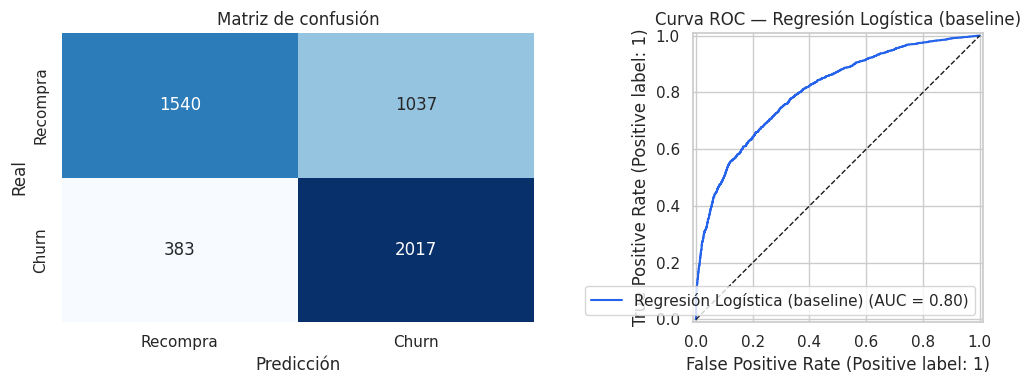


  Regresión Logística (baseline)  (threshold = 0.5)
              precision    recall  f1-score   support

       Churn       0.66      0.84      0.74      2400
    Recompra       0.80      0.60      0.68      2577

    accuracy                           0.71      4977
   macro avg       0.73      0.72      0.71      4977
weighted avg       0.73      0.71      0.71      4977

AUC-ROC: 0.8047 | AUC-PR: 0.8232 | Kappa: 0.4339 | MCC: 0.4495


In [19]:
N_TRIALS = 100

study = optuna.create_study(direction="maximize")
print(f"Optimizando {mejor_nombre} ({N_TRIALS} trials)...")
study.optimize(make_objective(mejor_nombre), n_trials=N_TRIALS, show_progress_bar=True)
print(f"Mejor AUC interno (validación Optuna): {study.best_value:.4f}")
print(f"Hiperparámetros óptimos: {study.best_params}")

# Modelo optimizado por Optuna
modelo_opt = build_best_model(mejor_nombre, study.best_params)
modelo_opt.fit(X_train, y_train)
y_prob_opt = modelo_opt.predict_proba(X_test)[:, 1]
auc_opt = roc_auc_score(y_test, y_prob_opt)

# Baseline del modelo ganador (configuración por defecto). Se envuelve en un Pipeline
# para que todo el flujo posterior trabaje con X sin escalar de forma homogénea.
def build_baseline_model(nombre):
    if nombre == "Regresión Logística":
        return Pipeline([("scaler", StandardScaler()),
                         ("lr", LogisticRegression(class_weight="balanced",
                                                   max_iter=2000, random_state=RANDOM_STATE))])
    if nombre == "Random Forest":
        return RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                      random_state=RANDOM_STATE, n_jobs=-1)
    if nombre == "Extra Trees":
        return ExtraTreesClassifier(n_estimators=300, class_weight="balanced",
                                    random_state=RANDOM_STATE, n_jobs=-1)
    if nombre == "Gradient Boosting (sklearn)":
        return GradientBoostingClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                          subsample=0.8, random_state=RANDOM_STATE)
    if nombre == "XGBoost":
        return xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8,
                                 colsample_bytree=0.8, scale_pos_weight=scale_pw, eval_metric="auc",
                                 random_state=RANDOM_STATE, n_jobs=-1)
    return lgb.LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, num_leaves=40,
                              subsample=0.8, colsample_bytree=0.8, class_weight="balanced",
                              random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)

modelo_base = build_baseline_model(mejor_nombre)
modelo_base.fit(X_train, y_train)
y_prob_base = modelo_base.predict_proba(X_test)[:, 1]
auc_base = roc_auc_score(y_test, y_prob_base)

# Selección final: la optimización no siempre supera a la configuración por defecto
# (en modelos bien regularizados esta ya puede estar cerca del óptimo). Se conserva
# el que mejor generaliza en el período de validación; si empatan, el más simple.
print(f"\n{mejor_nombre}: AUC baseline {auc_base:.4f}  |  AUC Optuna {auc_opt:.4f}")
if auc_opt > auc_base:
    best_model, auc_best, MODELO_FINAL = modelo_opt, auc_opt, f"{mejor_nombre} (Optuna)"
    print("La optimización mejora al baseline: se usa el modelo optimizado.")
else:
    best_model, auc_best, MODELO_FINAL = modelo_base, auc_base, f"{mejor_nombre} (baseline)"
    print("La optimización no supera al baseline: se conserva la configuración por defecto, más simple.")

y_prob_best = best_model.predict_proba(X_test)[:, 1]
print(f"\nModelo final seleccionado: {MODELO_FINAL}  |  AUC test = {auc_best:.4f}")
resultados.append(metricas(y_test, y_prob_best, tag=MODELO_FINAL))

## 11. Comparativa

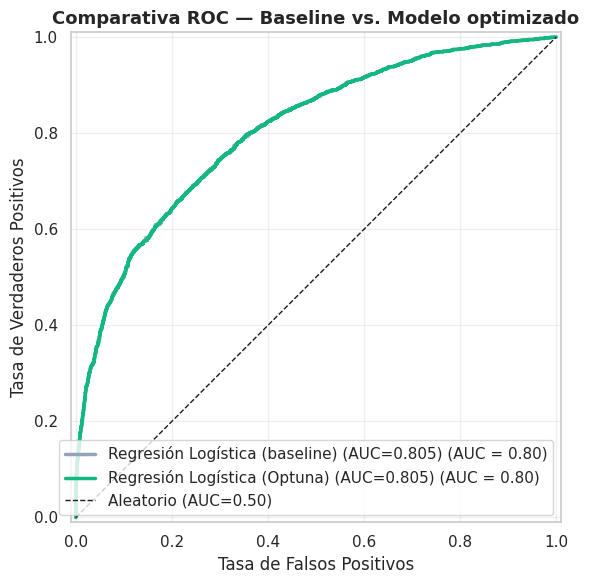

In [20]:
# Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))
curvas = {f"{mejor_nombre} (baseline)": y_prob_base, f"{mejor_nombre} (Optuna)": y_prob_opt}
for (name, probs), color in zip(curvas.items(), [PALETA["gris"], PALETA["verde"]]):
    RocCurveDisplay.from_predictions(
        y_test, probs, name=f"{name} (AUC={roc_auc_score(y_test, probs):.3f})",
        ax=ax, color=color, linewidth=2.5)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatorio (AUC=0.50)")
ax.set_title("Comparativa ROC — Baseline vs. Modelo optimizado", fontweight="bold", fontsize=13)
ax.set_xlabel("Tasa de Falsos Positivos"); ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 12. Elección del umbral según el coste de negocio

El AUC mide lo bien que el modelo ordena a los clientes, pero para actuar hace falta una decisión de sí o no: ¿se lanza una acción de retención sobre este cliente? Esa decisión depende de un umbral, y el umbral hay que fijarlo según lo que cuesta cada error, no dejarlo en 0.5.

Conviene pensar en los dos errores posibles al detectar churn (aquí el "positivo" es el cliente que no vuelve):

- Falso negativo: digo que el cliente volverá y se acaba marchando. Pierdo un cliente que quizá podría haber retenido. Cuesta caro.
- Falso positivo: digo que está en riesgo pero iba a volver igual. Me gasto un incentivo de más. Cuesta poco.

Si retener a un cliente que se iba vale del orden de 10 veces más que un cupón desperdiciado, conviene ser agresivos detectando churn: bajar el umbral captura a más clientes en riesgo aunque se pierda algo de precisión.

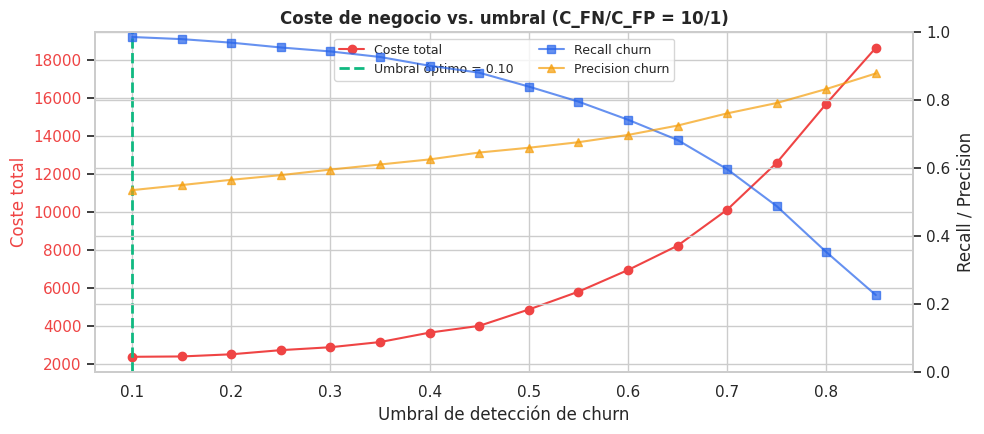

,threshold,recall_churn,precision_churn,coste_total
0,0.10,0.986,0.536,"2,381"
1,0.15,0.980,0.551,"2,399"
2,0.20,0.970,0.566,"2,513"
3,0.25,0.955,0.580,"2,731"
4,0.30,0.944,0.596,"2,884"
5,0.35,0.927,0.611,"3,156"
6,0.40,0.902,0.626,"3,652"
7,0.45,0.881,0.646,"4,007"
8,0.50,0.840,0.660,"4,867"
9,0.55,0.796,0.677,"5,803"



Con C_FN/C_FP = 10, el umbral que minimiza el coste es 0.10.


In [21]:
# Probabilidad de CHURN = 1 - P(recompra)
y_prob_churn = 1 - y_prob_lr
y_churn_real = 1 - y_test.values     # 1 = el cliente NO recompró (churn real)

C_FN, C_FP = 10, 1   # coste relativo: perder un cliente vs. incentivo desperdiciado

thresholds = np.arange(0.10, 0.90, 0.05)
filas = []
for t in thresholds:
    pc = (y_prob_churn >= t).astype(int)
    tp = ((pc == 1) & (y_churn_real == 1)).sum()
    fp = ((pc == 1) & (y_churn_real == 0)).sum()
    fn = ((pc == 0) & (y_churn_real == 1)).sum()
    filas.append({"threshold": t,
                  "recall_churn": tp/(tp+fn) if (tp+fn) else 0,
                  "precision_churn": tp/(tp+fp) if (tp+fp) else 0,
                  "coste_total": fn*C_FN + fp*C_FP})
df_thr = pd.DataFrame(filas)
t_opt = df_thr.loc[df_thr["coste_total"].idxmin(), "threshold"]

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(df_thr["threshold"], df_thr["coste_total"], color=PALETA["rojo"], marker="o", label="Coste total")
ax1.axvline(t_opt, color=PALETA["verde"], linestyle="--", linewidth=2, label=f"Umbral óptimo = {t_opt:.2f}")
ax1.set_xlabel("Umbral de detección de churn"); ax1.set_ylabel("Coste total", color=PALETA["rojo"])
ax1.tick_params(axis="y", labelcolor=PALETA["rojo"])
ax2 = ax1.twinx()
ax2.plot(df_thr["threshold"], df_thr["recall_churn"], color=PALETA["azul"], marker="s", alpha=0.7, label="Recall churn")
ax2.plot(df_thr["threshold"], df_thr["precision_churn"], color=PALETA["ambar"], marker="^", alpha=0.7, label="Precision churn")
ax2.set_ylabel("Recall / Precision"); ax2.set_ylim(0, 1)
ax1.set_title(f"Coste de negocio vs. umbral (C_FN/C_FP = {C_FN}/{C_FP})", fontweight="bold")
l1, lab1 = ax1.get_legend_handles_labels(); l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lab1+lab2, loc="upper center", ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

display(df_thr.style.format({"threshold": "{:.2f}", "recall_churn": "{:.3f}",
        "precision_churn": "{:.3f}", "coste_total": "{:,.0f}"})
        .highlight_min(subset=["coste_total"], color="#D1FAE5"))
print(f"\nCon C_FN/C_FP = {C_FN}, el umbral que minimiza el coste es {t_opt:.2f}.")

## 13. Scoring y segmentación comercial

Se aplica el modelo a la cartera para dar a cada cliente su probabilidad de recompra y traducirla en tres segmentos sobre los que negocio puede actuar.

| Segmento | Probabilidad de recompra | Acción comercial |
|---|---|---|
| 🟢 Alta retención | ≥ 70% | Fidelización: programa de puntos, acceso anticipado |
| 🟡 Riesgo moderado | 40–70% | Nurturing: newsletter, descuento personalizado |
| 🔴 Churn probable | < 40% | Retención urgente: oferta de reactivación |

Distribución de clientes por segmento (snapshot 2011-06-12):
  🔴 Churn Probable        2554 clientes (51.3%)
  🟡 Riesgo Moderado       1245 clientes (25.0%)
  🟢 Alta Retención        1178 clientes (23.7%)


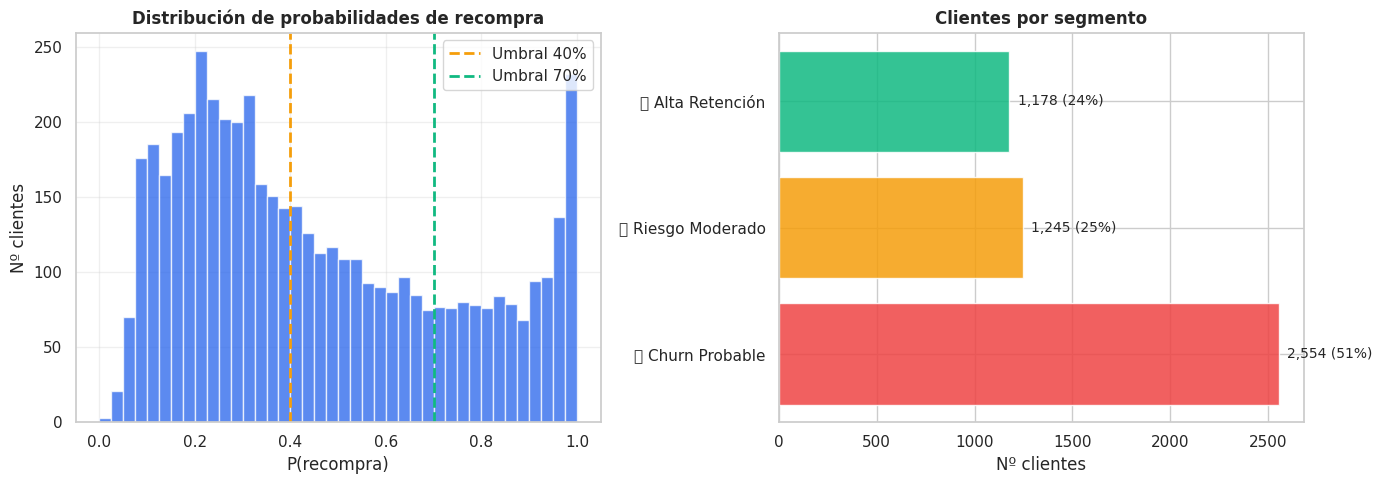


Top 10 clientes con mayor riesgo de abandono (acción inmediata):


,Customer ID,P(Recompra),Gasto (log),Frec (log),Días sin comprar
1081,13687,0.0%,9.382766,0.693147,257
1262,13902,2.2%,10.436943,1.791759,451
1423,14095,2.2%,1.373716,0.693147,542
4833,18115,3.2%,2.370244,0.693147,517
389,12846,3.4%,2.808197,0.693147,501
1662,14380,3.5%,3.911223,0.693147,501
206,12606,3.5%,3.091042,0.693147,501
4364,17557,3.7%,3.555348,0.693147,552
226,12636,3.9%,4.955827,0.693147,558
97,12466,4.2%,4.055777,0.693147,501


In [22]:
# Puntuamos el snapshot MÁS RECIENTE (test) = estado actual de cada cliente
df_scoring = df_test_full.copy()
df_scoring['Prob_Recompra'] = best_model.predict_proba(df_scoring[FEATURES])[:, 1]

def segmentar(p):
    if p >= 0.70: return "🟢 Alta Retención"
    if p >= 0.40: return "🟡 Riesgo Moderado"
    return "🔴 Churn Probable"
df_scoring['Segmento'] = df_scoring['Prob_Recompra'].apply(segmentar)

seg = df_scoring['Segmento'].value_counts()
print(f"Distribución de clientes por segmento (snapshot {CUTOFF_TEST.date()}):")
for s, n in seg.items():
    print(f"  {s:<22} {n:>5} clientes ({n/len(df_scoring)*100:.1f}%)")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.hist(df_scoring['Prob_Recompra'], bins=40, color=PALETA["azul"], alpha=0.75, edgecolor="white")
a1.axvline(0.40, color=PALETA["ambar"], linestyle="--", linewidth=2, label="Umbral 40%")
a1.axvline(0.70, color=PALETA["verde"], linestyle="--", linewidth=2, label="Umbral 70%")
a1.set_title("Distribución de probabilidades de recompra", fontweight="bold")
a1.set_xlabel("P(recompra)"); a1.set_ylabel("Nº clientes"); a1.legend(); a1.grid(alpha=0.3)

col = {"🟢 Alta Retención": PALETA["verde"], "🟡 Riesgo Moderado": PALETA["ambar"], "🔴 Churn Probable": PALETA["rojo"]}
bars = a2.barh(list(seg.index), list(seg.values), color=[col[s] for s in seg.index], alpha=0.85)
a2.bar_label(bars, labels=[f"{v:,} ({v/len(df_scoring)*100:.0f}%)" for v in seg.values], padding=6, fontsize=10)
a2.set_title("Clientes por segmento", fontweight="bold"); a2.set_xlabel("Nº clientes")
plt.tight_layout(); plt.show()

churn_top = (df_scoring[df_scoring['Segmento'] == "🔴 Churn Probable"]
             .sort_values('Prob_Recompra')
             .head(10)[['Customer ID', 'Prob_Recompra', 'Monetary_Gasto',
                        'Frecuencia_Compras', 'Recency_Dias']]
             .rename(columns={'Prob_Recompra': 'P(Recompra)', 'Monetary_Gasto': 'Gasto (log)',
                              'Frecuencia_Compras': 'Frec (log)', 'Recency_Dias': 'Días sin comprar'}))
print("\nTop 10 clientes con mayor riesgo de abandono (acción inmediata):")
display(churn_top.style.format({'P(Recompra)': '{:.1%}'}))

## 14. Explicabilidad con SHAP


In [23]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"]); import shap

print("Calculando valores SHAP sobre el test set...")

IS_PIPELINE_LR = hasattr(best_model, "named_steps") and "lr" in best_model.named_steps

if IS_PIPELINE_LR:
    # Para LR: LinearExplainer sobre el step LR con datos ya escalados
    lr_step  = best_model.named_steps["lr"]
    sc_step  = best_model.named_steps["scaler"]
    X_shap   = pd.DataFrame(sc_step.transform(X_test), columns=FEATURES, index=X_test.index)
    explainer   = shap.LinearExplainer(lr_step, X_shap, feature_perturbation="interventional")
    sv          = explainer.shap_values(X_shap)
else:
    # Para modelos de árbol: TreeExplainer estándar
    X_shap      = X_test
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    sv          = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"SHAP calculado para {len(X_shap)} clientes.")

Background dataset has 4977 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4977 when initializing the masker.


Calculando valores SHAP sobre el test set...
SHAP calculado para 4977 clientes.


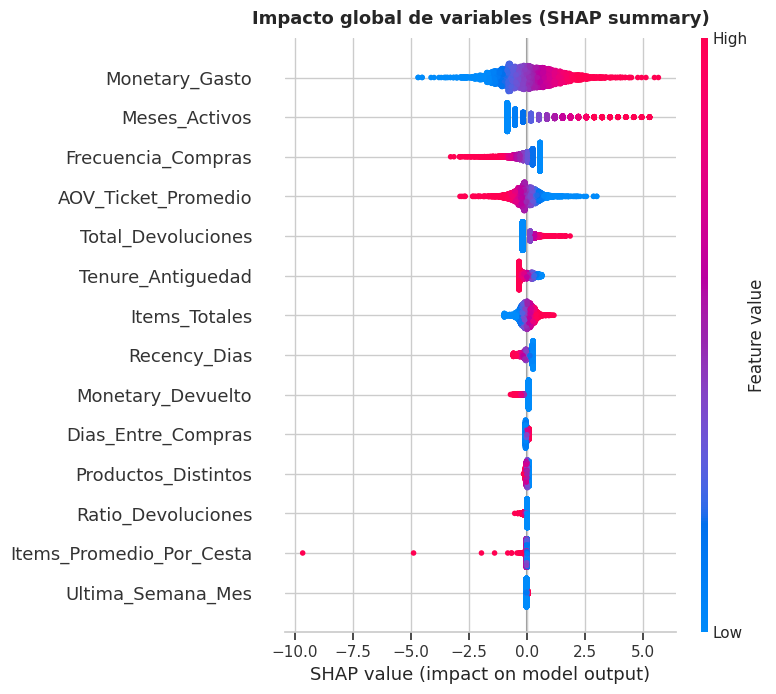

In [24]:
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_shap, feature_names=FEATURES, show=False, max_display=14)
plt.title("Impacto global de variables (SHAP summary)", fontweight="bold", fontsize=13, pad=10)
plt.tight_layout(); plt.show()

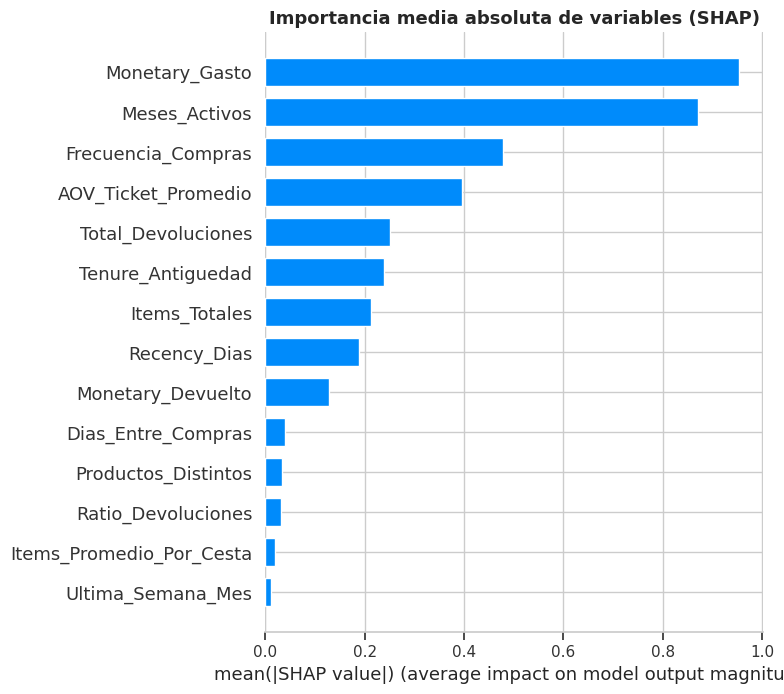


Ranking de importancia (SHAP medio |Δ|):
   1. Monetary_Gasto               0.9544
   2. Meses_Activos                0.8705
   3. Frecuencia_Compras           0.4785
   4. AOV_Ticket_Promedio          0.3954
   5. Total_Devoluciones           0.2504
   6. Tenure_Antiguedad            0.2395
   7. Items_Totales                0.2117
   8. Recency_Dias                 0.1882
   9. Monetary_Devuelto            0.1279
  10. Dias_Entre_Compras           0.0385
  11. Productos_Distintos          0.0333
  12. Ratio_Devoluciones           0.0316
  13. Items_Promedio_Por_Cesta     0.0184
  14. Ultima_Semana_Mes            0.0109


In [25]:
shap.summary_plot(sv, X_shap, feature_names=FEATURES, plot_type="bar", show=False, max_display=14)
plt.title("Importancia media absoluta de variables (SHAP)", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=FEATURES).sort_values(ascending=False)
print("\nRanking de importancia (SHAP medio |Δ|):")
for i, (f, v) in enumerate(mean_abs_shap.items(), 1):
    print(f"  {i:2}. {f:<28} {v:.4f}")

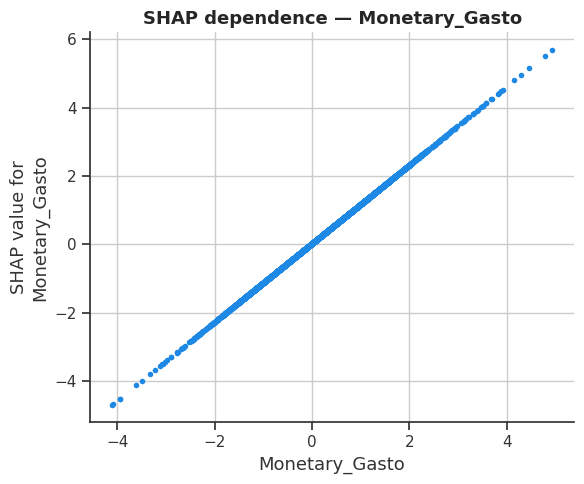

In [26]:
top_feature = mean_abs_shap.index[0]
shap.dependence_plot(top_feature, sv, X_shap, feature_names=FEATURES, interaction_index=None, show=False)
plt.title(f"SHAP dependence — {top_feature}", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

Cliente en riesgo — ID: 13888 | P(recompra) = 0.0%


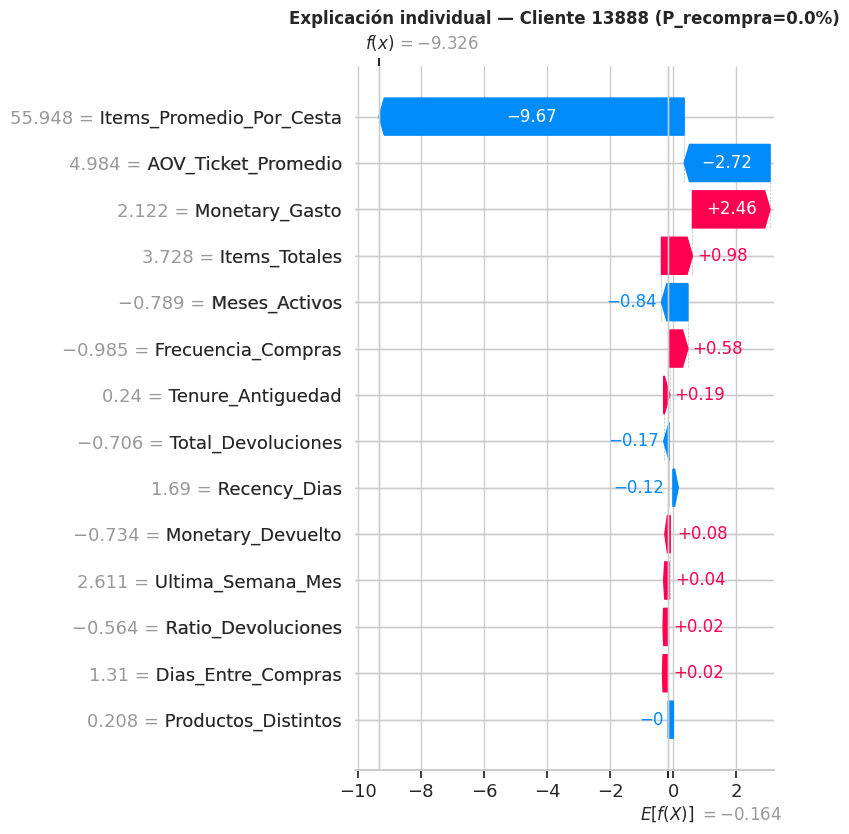

In [27]:
# Explicación individual de un cliente en riesgo
pos = int(np.argmin(y_prob_best))
idx = X_shap.index[pos]
cid = df_ml.loc[idx, 'Customer ID'] if idx in df_ml.index else str(idx)
prob = y_prob_best[pos]
print(f"Cliente en riesgo — ID: {cid} | P(recompra) = {prob:.1%}")

base = explainer.expected_value
if isinstance(base, (list, np.ndarray)):
    base = base[1] if len(np.atleast_1d(base)) > 1 else float(np.atleast_1d(base)[0])

exp = shap.Explanation(values=sv[pos], base_values=base,
                       data=X_shap.iloc[pos].values, feature_names=FEATURES)
shap.plots.waterfall(exp, show=False, max_display=14)
plt.title(f"Explicación individual — Cliente {cid} (P_recompra={prob:.1%})",
          fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()

## 15. Resumen ejecutivo y próximos pasos

In [28]:
print("═"*62)
print("              RESUMEN EJECUTIVO DEL PROYECTO")
print("═"*62)
print(f"  Modelo seleccionado   : {MODELO_FINAL}")
print(f"  Validación            : walk-forward temporal (2 snapshots de 180 d)")
print(f"  ROC-AUC en test       : {auc_best:.4f}")
print(f"  AUC baseline / Optuna : {auc_base:.4f} / {auc_opt:.4f}")
print(f"  Umbral de acción      : {t_opt:.2f} (minimiza coste de negocio)")
print(f"  Clientes en cartera   : {len(df_scoring):,}")
print()
print("  SEGMENTACIÓN COMERCIAL:")
for s, n in seg.items():
    print(f"    {s}: {n:>5} ({n/len(df_scoring)*100:.0f}%)")
print()
print("  TOP 3 VARIABLES PREDICTORAS (SHAP):")
for i, (f, v) in enumerate(mean_abs_shap.head(3).items(), 1):
    print(f"    {i}. {f}  (SHAP={v:.4f})")
print("═"*62)

══════════════════════════════════════════════════════════════
              RESUMEN EJECUTIVO DEL PROYECTO
══════════════════════════════════════════════════════════════
  Modelo seleccionado   : Regresión Logística (baseline)
  Validación            : walk-forward temporal (2 snapshots de 180 d)
  ROC-AUC en test       : 0.8047
  AUC baseline / Optuna : 0.8047 / 0.8046
  Umbral de acción      : 0.10 (minimiza coste de negocio)
  Clientes en cartera   : 4,977

  SEGMENTACIÓN COMERCIAL:
    🔴 Churn Probable:  2554 (51%)
    🟡 Riesgo Moderado:  1245 (25%)
    🟢 Alta Retención:  1178 (24%)

  TOP 3 VARIABLES PREDICTORAS (SHAP):
    1. Monetary_Gasto  (SHAP=0.9544)
    2. Meses_Activos  (SHAP=0.8705)
    3. Frecuencia_Compras  (SHAP=0.4785)
══════════════════════════════════════════════════════════════


### Conclusiones

1. El modelo se entrena en un período y se evalúa prediciendo los 6 meses siguientes (walk-forward). Esto corrige el split inicial (ordenar por `Recency`), que inflaba el AUC al dejar un test demasiado fácil (84% de recompra frente al 44% del train).
2. El mejor modelo es la regresión logística, con un AUC en torno a 0.80 en test, por delante de Random Forest, Extra Trees, Gradient Boosting, XGBoost y LightGBM, y la optimización con Optuna no logró mejorar su configuración por defecto, que ya estaba cerca del óptimo, así que se conserva esta por simplicidad. No es casualidad: las variables RFM transformadas con `log1p` tienen una relación casi lineal con el target, y con unos 4.000 clientes los modelos complejos no encuentran estructura no lineal extra que aprovechar. Aquí un modelo simple, interpretable y estable es la mejor opción, y además es el más fácil de explicar a negocio.
3. El problema está cerca de su techo con datos de historial de cliente. Se probaron variables adicionales de momentum y tendencia y no mejoraban el AUC, así que se descartaron. La palanca de mejora real está en enriquecer los datos, no en cambiar de algoritmo.
4. Según SHAP, los principales motores del modelo son el gasto acumulado (Monetary), la consistencia temporal (Meses Activos) y la frecuencia de compra. Recency pesa de forma más indirecta porque su señal ya está recogida en buena parte por esas variables, aunque a nivel univariante sigue siendo muy informativa.
5. Los tres segmentos y el umbral basado en coste convierten el score en un plan de acción concreto y alineado con la economía real: perder un cliente cuesta mucho más que un incentivo.

### Próximos pasos

1. Validación walk-forward con más cortes deslizantes, para estimar mejor la variabilidad del rendimiento.
2. Enriquecer las variables, que es donde más se puede ganar: categorías de producto a partir de `Description` con NLP (TF-IDF o LDA), estacionalidad y señales de canal o campaña.
3. Umbral por valor de cliente: ser más agresivo detectando churn en clientes de alto CLV.
4. Combinar la probabilidad de recompra con el Customer Lifetime Value para priorizar las acciones de mayor retorno.
5. Medir el impacto real con un test A/B: no solo el AUC, sino el aumento de retención que consiguen las campañas guiadas por el modelo.